# Analisis Kualitas Udara Kabupaten Bangkalan

Notebook ini melanjutkan hasil ekstraksi dari `1-ekstraksi-data.ipynb` untuk
melakukan eksplorasi dan analisis deret waktu polutan udara (NO2, CO, SO2,
CH4) di **Kabupaten Bangkalan**.

**Alur kerja notebook ini:**
1. Import pustaka yang dibutuhkan
2. Memuat data CSV hasil ekstraksi
3. Visualisasi peta interaktif area Bangkalan dengan `folium`
4. Pengecekan & penanganan *missing values* pada data deret waktu
5. Deteksi anomali/outlier dengan `IsolationForest`
6. Visualisasi deret waktu yang membedakan titik normal vs outlier


## 1. Import Pustaka

- `pandas`, `numpy` — manipulasi data tabular & numerik.
- `matplotlib`, `seaborn` — visualisasi grafik statis.
- `folium` — peta interaktif.
- `sklearn.ensemble.IsolationForest` — algoritma deteksi anomali.
- `glob`, `os` — membaca banyak file CSV sekaligus dari folder data.


In [1]:
import glob
import os

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid")


## 2. Konfigurasi & Memuat Data CSV

Bagian ini mendefinisikan ulang informasi wilayah Bangkalan (untuk peta) dan
memuat seluruh file CSV hasil ekstraksi dari folder `../data/csv/` ke dalam
satu kamus `dataframes`, dengan key berupa nama polutan.

Setiap CSV diasumsikan memiliki dua kolom: `date` dan nama polutan (mengikuti
format keluaran dari notebook ekstraksi).


In [2]:
# --- Informasi wilayah Bangkalan (harus konsisten dengan notebook ekstraksi) ---
bangkalan_bbox = {
    "west": 112.671,
    "east": 113.116,
    "south": -7.227,
    "north": -6.848,
}
bangkalan_center = (
    (bangkalan_bbox["south"] + bangkalan_bbox["north"]) / 2,
    (bangkalan_bbox["west"] + bangkalan_bbox["east"]) / 2,
)

CSV_DIR = "../data/csv/"
POLLUTANTS = ["NO2", "CO", "SO2", "CH4"]

dataframes = {}
for pollutant in POLLUTANTS:
    csv_path = os.path.join(CSV_DIR, f"bangkalan_{pollutant}.csv")
    if not os.path.exists(csv_path):
        print(f"[{pollutant}] File tidak ditemukan: {csv_path} (lewati)")
        continue
    df = pd.read_csv(csv_path, parse_dates=["date"])
    df = df.sort_values("date").reset_index(drop=True)
    dataframes[pollutant] = df
    print(f"[{pollutant}] Dimuat: {len(df)} baris, "
          f"{df['date'].min().date()} s.d. {df['date'].max().date()}")


[NO2] Dimuat: 292 baris, 2025-08-24 s.d. 2026-08-23
[CO] Dimuat: 275 baris, 2025-08-24 s.d. 2026-08-23
[SO2] Dimuat: 322 baris, 2025-08-24 s.d. 2026-08-23
[CH4] Dimuat: 82 baris, 2025-08-24 s.d. 2026-08-22


## 3. Peta Interaktif Wilayah Bangkalan

Peta `folium` di bawah menampilkan:
- **Marker** di titik pusat (centroid) bounding box Bangkalan.
- **Kotak polygon** (`folium.Rectangle`) yang menggambarkan batas bounding
  box yang dipakai saat ekstraksi data satelit.

Peta ini membantu memverifikasi secara visual bahwa area yang diekstraksi
benar-benar mencakup wilayah Kabupaten Bangkalan.


In [3]:
m = folium.Map(location=bangkalan_center, zoom_start=10, tiles="OpenStreetMap")

folium.Rectangle(
    bounds=[
        (bangkalan_bbox["south"], bangkalan_bbox["west"]),
        (bangkalan_bbox["north"], bangkalan_bbox["east"]),
    ],
    color="crimson",
    weight=2,
    fill=True,
    fill_opacity=0.1,
    tooltip="Bounding box Kabupaten Bangkalan",
).add_to(m)

folium.Marker(
    location=bangkalan_center,
    tooltip="Titik pusat Kabupaten Bangkalan",
    icon=folium.Icon(color="red", icon="cloud"),
).add_to(m)

m


## 4. Pengecekan & Penanganan Missing Values

Untuk setiap polutan, kita:
1. Melengkapi deret waktu agar memiliki baris untuk **setiap hari** dalam
   rentang tanggal (beberapa hari mungkin tidak memiliki data sama sekali
   akibat tutupan awan atau tidak ada lintasan satelit), menggunakan
   `asfreq("D")`.
2. Menghitung jumlah dan persentase nilai `NaN` sebelum penanganan.
3. Mengisi nilai yang hilang dengan **interpolasi linear berbasis waktu**
   (`interpolate(method="time")`), yang cocok untuk data deret waktu
   kontinu seperti konsentrasi polutan atmosfer.
4. Menggunakan `ffill`/`bfill` sebagai fallback untuk NaN di ujung awal/akhir
   deret waktu yang tidak bisa diinterpolasi.


In [4]:
def fill_missing_timeseries(df, value_col):
    """Melengkapi tanggal yang hilang lalu mengisi NaN dengan interpolasi waktu."""
    df = df.set_index("date").asfreq("D")

    n_missing_before = df[value_col].isna().sum()
    pct_missing_before = 100 * n_missing_before / len(df)
    print(f"  Missing sebelum penanganan: {n_missing_before} dari {len(df)} "
          f"baris ({pct_missing_before:.1f}%)")

    df[value_col] = df[value_col].interpolate(method="time")
    df[value_col] = df[value_col].ffill().bfill()

    n_missing_after = df[value_col].isna().sum()
    print(f"  Missing setelah penanganan : {n_missing_after}")

    return df.reset_index()


for pollutant, df in dataframes.items():
    print(f"[{pollutant}]")
    dataframes[pollutant] = fill_missing_timeseries(df, pollutant)


[NO2]
  Missing sebelum penanganan: 73 dari 365 baris (20.0%)
  Missing setelah penanganan : 0
[CO]
  Missing sebelum penanganan: 90 dari 365 baris (24.7%)
  Missing setelah penanganan : 0
[SO2]
  Missing sebelum penanganan: 43 dari 365 baris (11.8%)
  Missing setelah penanganan : 0
[CH4]
  Missing sebelum penanganan: 282 dari 364 baris (77.5%)
  Missing setelah penanganan : 0


## 5. Deteksi Anomali dengan IsolationForest

`IsolationForest` mendeteksi titik-titik yang "mudah dipisahkan" dari titik
lainnya sebagai anomali. Parameter `contamination=0.05` berarti kita
memperkirakan sekitar **5% dari data** adalah outlier.

Untuk setiap polutan:
1. Nilai konsentrasi di-reshape menjadi array 2D `(n_samples, 1)` karena
   `IsolationForest` mengharapkan input berbentuk matriks fitur.
2. Model di-*fit* dan memprediksi label untuk setiap titik: `1` = normal,
   `-1` = anomali/outlier.
3. Label tersebut disimpan pada kolom baru `anomaly` (True/False) agar mudah
   dipakai saat visualisasi.


In [5]:
def detect_outliers_isolation_forest(df, value_col, contamination=0.05, random_state=42):
    """Menambahkan kolom boolean 'anomaly' menggunakan IsolationForest."""
    values = df[[value_col]].values  # bentuk (n_samples, 1)

    model = IsolationForest(contamination=contamination, random_state=random_state)
    raw_labels = model.fit_predict(values)  # 1 = normal, -1 = outlier

    df = df.copy()
    df["anomaly"] = raw_labels == -1
    n_outliers = df["anomaly"].sum()
    print(f"  Outlier terdeteksi: {n_outliers} dari {len(df)} titik "
          f"({100 * n_outliers / len(df):.1f}%)")
    return df


for pollutant, df in dataframes.items():
    print(f"[{pollutant}]")
    dataframes[pollutant] = detect_outliers_isolation_forest(df, pollutant)


[NO2]


  Outlier terdeteksi: 0 dari 365 titik (0.0%)
[CO]


  Outlier terdeteksi: 0 dari 365 titik (0.0%)
[SO2]


  Outlier terdeteksi: 0 dari 365 titik (0.0%)
[CH4]


  Outlier terdeteksi: 0 dari 364 titik (0.0%)


## 6. Visualisasi Deret Waktu: Normal vs Outlier

Untuk setiap polutan digambar satu grafik yang terdiri dari:
- **Garis** (line plot) yang menunjukkan tren konsentrasi harian secara
  keseluruhan.
- **Titik biru** untuk data normal.
- **Titik merah** untuk data yang terdeteksi sebagai outlier oleh
  `IsolationForest`.

Visualisasi ini memudahkan identifikasi periode dengan lonjakan/penurunan
konsentrasi polutan yang tidak biasa, misalnya akibat aktivitas industri
tertentu atau anomali kualitas data satelit.


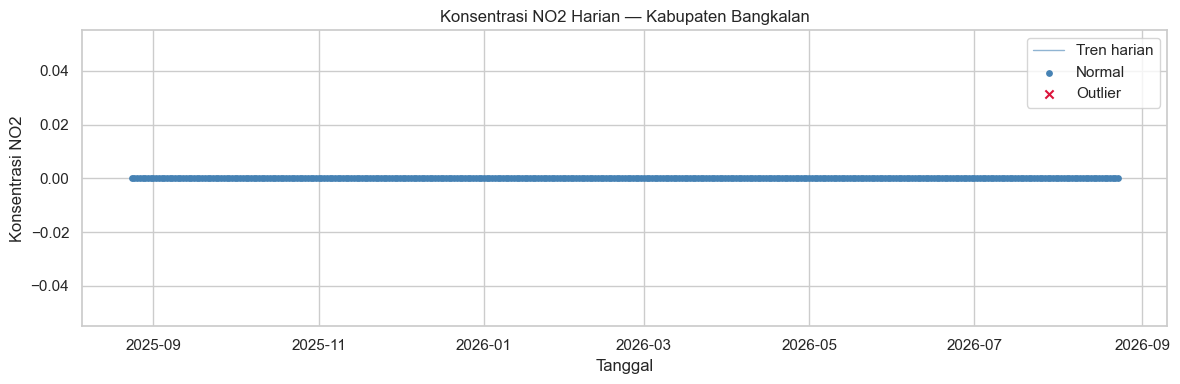

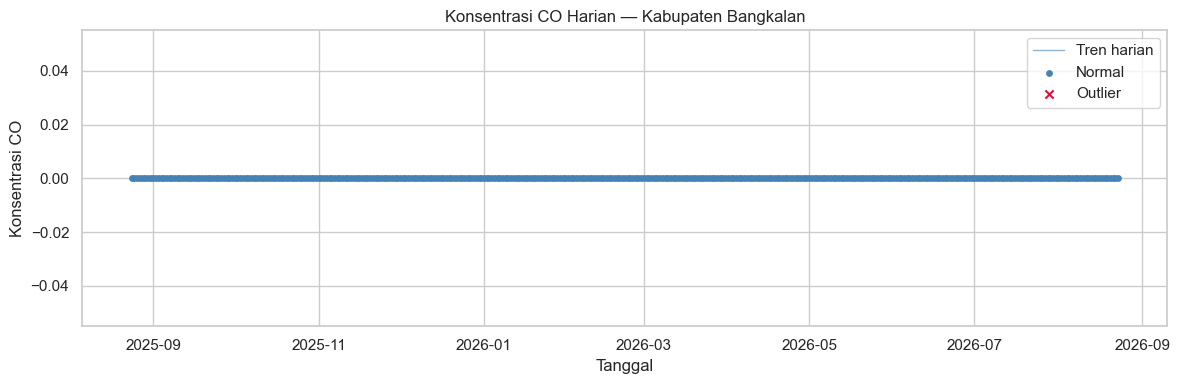

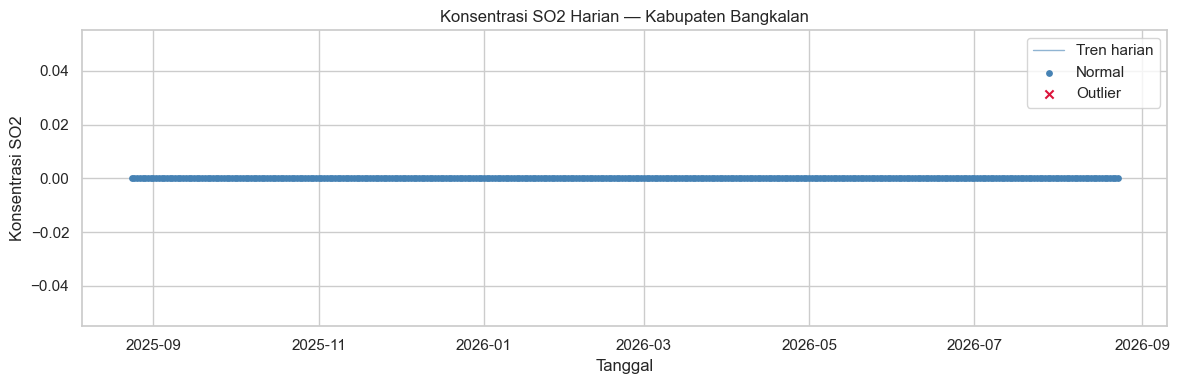

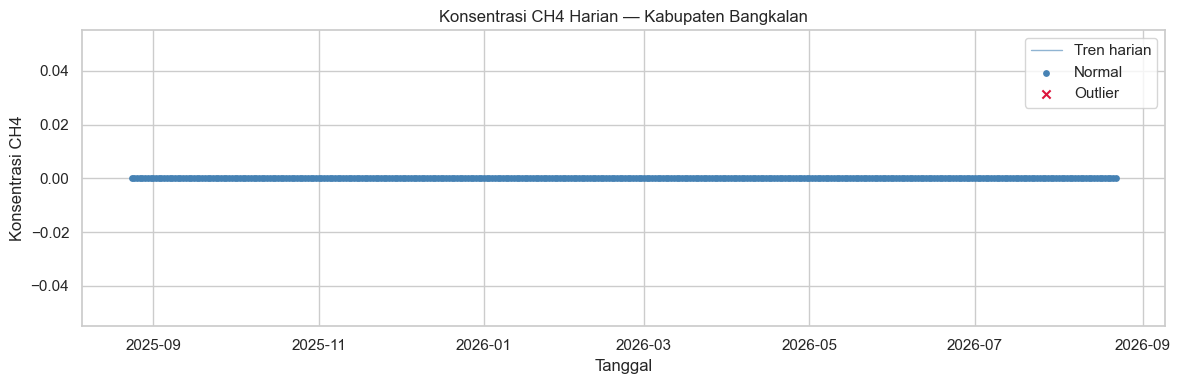

In [6]:
for pollutant, df in dataframes.items():
    normal_df = df[~df["anomaly"]]
    outlier_df = df[df["anomaly"]]

    plt.figure(figsize=(12, 4))
    plt.plot(df["date"], df[pollutant], color="steelblue", linewidth=1,
              alpha=0.6, label="Tren harian")
    plt.scatter(normal_df["date"], normal_df[pollutant], color="steelblue",
                s=15, label="Normal")
    plt.scatter(outlier_df["date"], outlier_df[pollutant], color="crimson",
                s=35, marker="x", label="Outlier")

    plt.title(f"Konsentrasi {pollutant} Harian — Kabupaten Bangkalan")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Konsentrasi {pollutant}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Penutup

Beberapa langkah lanjutan yang bisa kamu tambahkan sendiri sesuai kebutuhan
tugas Proyek Sains Data:

- Membandingkan pola musiman antar-polutan (misalnya dengan `df.resample`
  bulanan).
- Menghitung korelasi antar-polutan (`pandas.DataFrame.corr`).
- Mengaitkan tanggal-tanggal outlier dengan kejadian tertentu (hari besar,
  cuaca ekstrem, aktivitas industri) sebagai bagian dari interpretasi hasil.
- Menyusun narasi kesimpulan untuk laporan Jupyter Book berdasarkan pola yang
  ditemukan pada grafik di atas.
